## Name : Ramya Prajapati 

## Roll No. : 24BAM024

## Question 1

### Heart Disease Prediction Dataset Report
#### Selection of Data Domain:

Data Domain: Healthcare

Description: This dataset belongs to the healthcare domain and is used for predicting the presence or absence of heart disease in individuals based on their health metrics. It includes variables like age, cholesterol, blood pressure, max heart rate, and chest pain type. The model aims to predict the target variable, Heart Disease, indicating whether an individual has heart disease (1) or not (0).

In [1]:
# reading the data from CSV file

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("aiml_dataset_with_missing_diabetes.csv")

print(data)
print("No. of rows in given dataset is :", data.shape[0])
print("No. of coulmns in given dataset is :", data.shape[1])

     Age  Gender  Cholesterol  Blood Pressure  Heart Rate  Smoking  \
0     75  Female          228             119          66  Current   
1     48    Male          204             165          62  Current   
2     53    Male          234              91          67    Never   
3     69  Female          192              90          72  Current   
4     62  Female          172             163          93    Never   
..   ...     ...          ...             ...         ...      ...   
995   56  Female          269             111          86    Never   
996   78  Female          334             145          76    Never   
997   79    Male          151             179          81    Never   
998   60  Female          326             151          68      NaN   
999   53    Male          226             116          82  Current   

    Alcohol Intake  Exercise Hours Family History Diabetes Obesity  \
0            Heavy               1             No       No     Yes   
1              NaN 

In [2]:
# replacing the "None" value from "Alcohol Intake" Coulmn with "Never" word, because python consider "None" as missing value

df1 = data.copy()

df1.loc[df1.loc[:,"Alcohol Intake"].isna(), "Alcohol Intake"] = "Never"
print(df1.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      1000 non-null   int64  
 1   Gender                   1000 non-null   object 
 2   Cholesterol              1000 non-null   int64  
 3   Blood Pressure           1000 non-null   int64  
 4   Heart Rate               1000 non-null   int64  
 5   Smoking                  900 non-null    object 
 6   Alcohol Intake           1000 non-null   object 
 7   Exercise Hours           1000 non-null   int64  
 8   Family History           1000 non-null   object 
 9   Diabetes                 900 non-null    object 
 10  Obesity                  1000 non-null   object 
 11  Stress Level             900 non-null    float64
 12  Blood Sugar              1000 non-null   int64  
 13  Exercise Induced Angina  1000 non-null   object 
 14  Chest Pain Type          

In [31]:
import pandas as pd

df = df1

# Check for missing (null) values
print("Null Values in Dataset:")
print(df.isnull().sum())

# Check unique values in each column
print("\nUnique Values per Column:")
print(df.nunique())

# Check data types
print("\nData Types of Each Column:")
print(df.dtypes)


Null Values in Dataset:
Age                          0
Gender                       0
Cholesterol                  0
Blood Pressure               0
Heart Rate                   0
Smoking                    100
Alcohol Intake               0
Exercise Hours               0
Family History               0
Diabetes                   100
Obesity                      0
Stress Level               100
Blood Sugar                  0
Exercise Induced Angina      0
Chest Pain Type              0
Heart Disease                0
dtype: int64

Unique Values per Column:
Age                         55
Gender                       2
Cholesterol                200
Blood Pressure              90
Heart Rate                  40
Smoking                      3
Alcohol Intake               3
Exercise Hours              10
Family History               2
Diabetes                     2
Obesity                      2
Stress Level                10
Blood Sugar                130
Exercise Induced Angina      2
Chest 

## Question 2

In [32]:
#finding the number of columns with missing values
df2 = df1.copy()
df2 = df1.dropna(axis=1)
print("The number of coulmns with missing values is:" , df1.shape[1]-df2.shape[1])
missing_col = df1.columns[df1.isnull().any()]
print(missing_col)

The number of coulmns with missing values is: 3
Index(['Smoking', 'Diabetes', 'Stress Level'], dtype='object')


In [33]:
#finding the number of the rows with missing values
df3 = df1.copy()
df3 = df3.dropna(axis = 0)
print("The number of rows with missing values is:" , df1.shape[0]-df3.shape[0])

The number of rows with missing values is: 191


### filling the the missing values of stress level coulmn

In [6]:
df4 = df1.copy()
mean_sl = np.mean(df1.loc[~df1["Stress Level"].isna(), "Stress Level"].values)
df4.loc[df1["Stress Level"].isna(),"Stress Level"]=mean_sl
print(mean_sl)

5.648888888888889


In [7]:
#smoking

In [8]:
smoke_mode = df4.loc[: , "Smoking"].mode()[0]
df4.loc[df4["Smoking"].isna() , "Smoking"] = smoke_mode
print(smoke_mode)

Never


In [9]:
# Diabetes
dia_mode = df4.loc[ : , "Diabetes" ].mode()[0]
df4.loc[df4["Diabetes"].isna() , "Diabetes" ] = dia_mode
print(dia_mode)

No


In [10]:
df7 = df4.dropna(axis = 1)
print("The number of coulmns with missing values is:" , df1.shape[1]-df7.shape[1])

The number of coulmns with missing values is: 0


In [11]:
print(df4.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      1000 non-null   int64  
 1   Gender                   1000 non-null   object 
 2   Cholesterol              1000 non-null   int64  
 3   Blood Pressure           1000 non-null   int64  
 4   Heart Rate               1000 non-null   int64  
 5   Smoking                  1000 non-null   object 
 6   Alcohol Intake           1000 non-null   object 
 7   Exercise Hours           1000 non-null   int64  
 8   Family History           1000 non-null   object 
 9   Diabetes                 1000 non-null   object 
 10  Obesity                  1000 non-null   object 
 11  Stress Level             1000 non-null   float64
 12  Blood Sugar              1000 non-null   int64  
 13  Exercise Induced Angina  1000 non-null   object 
 14  Chest Pain Type          

## Question 3

In [12]:
# statistical analysis for numerical columns
print(df4.describe())

               Age  Cholesterol  Blood Pressure   Heart Rate  Exercise Hours  \
count  1000.000000  1000.000000       1000.0000  1000.000000     1000.000000   
mean     52.293000   249.939000        135.2810    79.204000        4.529000   
std      15.727126    57.914673         26.3883    11.486092        2.934241   
min      25.000000   150.000000         90.0000    60.000000        0.000000   
25%      39.000000   200.000000        112.7500    70.000000        2.000000   
50%      52.000000   248.000000        136.0000    79.000000        4.500000   
75%      66.000000   299.000000        159.0000    89.000000        7.000000   
max      79.000000   349.000000        179.0000    99.000000        9.000000   

       Stress Level  Blood Sugar  Heart Disease  
count   1000.000000  1000.000000    1000.000000  
mean       5.648889   134.941000       0.392000  
std        2.682209    36.699624       0.488441  
min        1.000000    70.000000       0.000000  
25%        3.000000   104.000

In [13]:
# mode for categorial columns
cat_cols = df4.select_dtypes(exclude=['number']).columns

modes = df4[cat_cols].mode().iloc[0]
print(modes)

Gender                               Female
Smoking                               Never
Alcohol Intake                        Heavy
Family History                           No
Diabetes                                 No
Obesity                                  No
Exercise Induced Angina                  No
Chest Pain Type            Non-anginal Pain
Name: 0, dtype: object


In [14]:
# mode for heart disease
mode_hd = df4["Heart Disease"].mode().iloc[0]
print("Yes" if mode_hd == 1 else "No")

No


In [15]:
#unique values

In [16]:
for i in df4.columns :
    print( i, ":", df4[i].unique(),":", df4[i].nunique()) 

Age : [75 48 53 69 62 77 64 60 37 63 67 43 44 46 45 74 76 58 31 66 79 32 41 36
 57 72 65 28 70 51 54 52 38 25 55 61 30 35 42 56 47 71 68 59 33 78 26 50
 27 39 40 29 73 49 34] : 55
Gender : ['Female' 'Male'] : 2
Cholesterol : [228 204 234 192 172 309 211 208 317 282 293 325 155 226 250 279 259 246
 298 297 287 177 276 265 273 197 319 313 179 227 262 311 230 306 216 189
 162 207 271 209 251 268 286 167 348 330 264 252 232 261 257 339 166 310
 180 331 307 247 243 290 223 161 241 154 203 205 184 291 210 215 336 242
 320 284 249 248 236 174 164 296 278 196 272 328 176 327 217 222 185 201
 237 175 224 294 238 270 195 281 199 345 170 256 153 183 347 221 200 277
 302 169 329 266 198 308 283 254 343 292 181 231 275 168 187 323 156 235
 300 344 267 178 159 213 255 285 335 295 158 229 349 315 326 193 191 341
 274 214 332 212 318 280 171 337 219 322 299 244 333 186 342 260 289 173
 324 340 151 240 163 269 220 188 314 338 334 194 190 258 206 157 239 245
 233 304 321 160 301 165 288 152 303 202 346 

## Question4

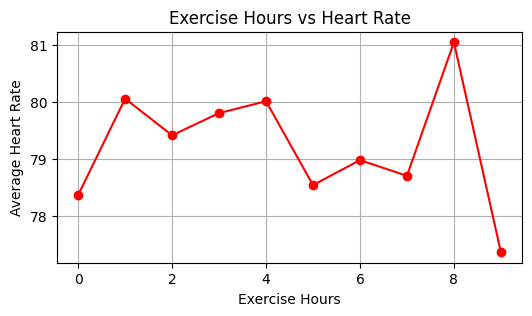

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df23 = df4

# Calculate the average heart rate for each exercise hour group
avg_heart_rate_per_exercise = df23.groupby("Exercise Hours")["Heart Rate"].mean()


plt.figure(figsize=(6, 3))
plt.plot(avg_heart_rate_per_exercise.index, avg_heart_rate_per_exercise.values, color='r', linestyle='-', marker='o')

# Set title and labels
plt.title("Exercise Hours vs Heart Rate")
plt.xlabel("Exercise Hours")
plt.ylabel("Average Heart Rate")
plt.grid()

# Show the plot
plt.show()


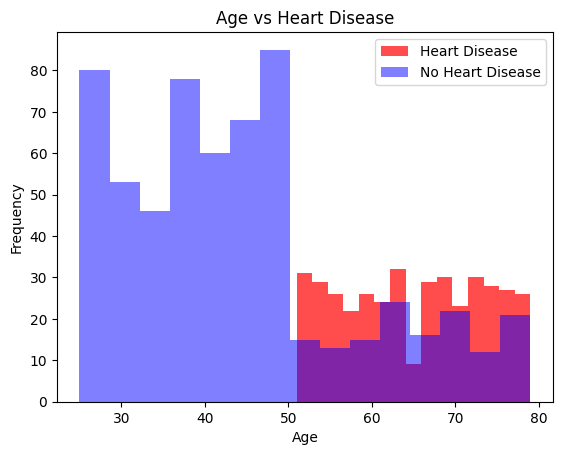

In [18]:
import matplotlib.pyplot as plt
df20 = df4

# Convert 'Heart Disease' to numeric if needed
df20["Heart Disease"] = df20["Heart Disease"].astype("category").cat.codes  



# Plot histogram
plt.hist(df20[df20["Heart Disease"] == 1]["Age"], bins=15, color="red", alpha=0.7, label="Heart Disease")
plt.hist(df20[df20["Heart Disease"] == 0]["Age"], bins=15, color="blue", alpha=0.5, label="No Heart Disease")

# Labels and title
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age vs Heart Disease")
plt.legend()

# Show plot
plt.show()


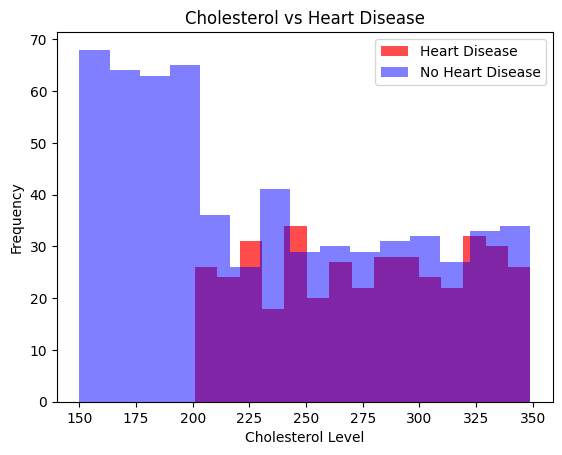

In [19]:
import matplotlib.pyplot as plt

df21 = df4
# Convert 'Heart Disease' to numeric if needed
df21["Heart Disease"] = df21["Heart Disease"].astype("category").cat.codes  



# Plot histogram
plt.hist(df21[df21["Heart Disease"] == 1]["Cholesterol"], bins=15, color="red", alpha=0.7, label="Heart Disease")
plt.hist(df21[df21["Heart Disease"] == 0]["Cholesterol"], bins=15, color="blue", alpha=0.5, label="No Heart Disease")

# Labels and title
plt.xlabel("Cholesterol Level")
plt.ylabel("Frequency")
plt.title("Cholesterol vs Heart Disease")
plt.legend()

# Show plot
plt.show()


## Question 5

In [28]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Load your dataset
df12 = df4  

# Define the target column
target_column = "Heart Disease" 

# Separate features (X) and target (y)
X = df12.drop(columns=[target_column])  # All columns except target
y = df12[target_column]  # Target column

categorical_cols = X.select_dtypes(include=['object', 'category']).columns  # Identify categorical columns


# Convert categorical columns to numeric using LabelEncoder
label_encoder = LabelEncoder()
for col in categorical_cols:
    X[col] = label_encoder.fit_transform(X[col])  # Encode each categorical column to numbers



mi_scores = mutual_info_classif(X, y, discrete_features='auto')


mi_df = pd.DataFrame({'Feature': X.columns, 'Mutual Information': mi_scores})

# Sort the DataFrame by Mutual Information
mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)

# Display the important features
print(mi_df)


                    Feature  Mutual Information
0                       Age            0.364671
2               Cholesterol            0.153392
10                  Obesity            0.024541
7            Exercise Hours            0.022393
1                    Gender            0.020984
9                  Diabetes            0.005748
3            Blood Pressure            0.000000
6            Alcohol Intake            0.000000
5                   Smoking            0.000000
4                Heart Rate            0.000000
8            Family History            0.000000
11             Stress Level            0.000000
12              Blood Sugar            0.000000
13  Exercise Induced Angina            0.000000
14          Chest Pain Type            0.000000


In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier


df14 = df4 


important_features = ["Age", "Cholesterol", "Gender", "Diabetes", "Heart Rate", "Stress Level", "Obesity"]
X = df14[important_features].copy()  # Explicitly create a copy
y = df14["Heart Disease"].copy()

# Encode categorical columns
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X.loc[:, col] = le.fit_transform(X[col])  # Use .loc to modify safely
    label_encoders[col] = le  # Save encoders

# Encode the target variable
y = LabelEncoder().fit_transform(y)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=30)

# User input for k
k = int(input("Enter the number of nearest neighbors (k): "))


knn_classifier = KNeighborsClassifier(n_neighbors=k, weights='distance')
knn_classifier.fit(X_train, y_train)
y_pred_class = knn_classifier.predict(X_test)


print("KNN Classification Results**")
print(f"Accuracy: {accuracy_score(y_test, y_pred_class) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_class))


Enter the number of nearest neighbors (k):  26


KNN Classification Results**
Accuracy: 95.50%

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96       122
           1       0.95      0.94      0.94        78

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



## Question 6

### Model Performance:

The classification model achieved 95.50% accuracy, which indicates a very high predictive power. The precision, recall, and F1-score values were also impressive, especially for class 0 (no heart disease), with values close to 1.0. This indicates that the model is very effective at identifying individuals without heart disease.

However, there was a slight decrease in performance for class 1 (patients with heart disease), as seen from the slightly lower recall and precision values. This suggests that the model might be biased toward predicting negative cases (no heart disease) more accurately than positive cases (heart disease).


### Key Features for Prediction:

The key predictors for heart disease include age, cholesterol levels, Diabetes, and Stress level, all of which are medical indicators known to correlate with heart disease risk.

These features are often used by doctors to assess a patient's likelihood of having heart disease, confirming the relevance of the dataset to real-world applications.

### Practical Implications:

The results of the model have significant real-world applications in healthcare, as it can assist doctors in identifying patients at risk of heart disease more efficiently. This predictive model could be used in medical practices or health screening tools to prioritize further diagnostic tests or preventive measures for patients at risk.

Given the high accuracy, this model could be integrated into healthcare systems to aid in early heart disease detection, potentially saving lives by enabling timely medical interventions.

In conclusion, the Heart Disease Prediction dataset provides valuable insights into the factors contributing to heart disease. The model’s performance indicates its potential use as a decision-support tool in healthcare, although there is always room for refinement to ensure balanced performance across all classes.